In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("pod_gpu_duty_cycle_anon.csv")

Next cell represents timestamp conversion. The column "timestamp_anon" stores time as a Unix timestamp (the number of seconds elapsed since January 1st, 1970) :this is a universal standard.  For example: 1662858720.0 seconds ÷ 60 ÷ 60 ÷ 24 ÷ 365 ≈ 52.7 years after 1970 = September 11, 2022

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp_anon"], unit="s")
df["timestamp"]

0        2022-09-11 01:12:00
1        2022-09-11 01:12:00
2        2022-09-11 01:12:00
3        2022-09-11 01:12:00
4        2022-09-11 01:12:00
                 ...        
157412   2022-09-12 00:00:00
157413   2022-09-12 00:00:00
157414   2022-09-12 00:00:00
157415   2022-09-12 00:00:00
157416   2022-09-12 00:00:00
Name: timestamp, Length: 157417, dtype: datetime64[ns]

In [4]:
# First, rows are sorted alphabetically by container_ip, 
# then within each container, rows are sorted chronologically by timestamp
df = df.sort_values(["container_ip", "timestamp"])


Top 6 Containers by Standard Deviation of GPU Utilization

Top 10 containers by standard deviation:
container_ip
2e6ae9139876748af8cf4e03e8d5cd77    34.218652
2a2ad10c55eff29ee870718a85944d13    33.317369
83cdea8775aa4c90f4cda237e9efe1d1    32.373111
0ec705c2842d35b28efbea446e2c9255    30.910298
3ed83727fd0a4a21f681882036a57972    29.724723
3de9cc1314ba06b9d4c8d66a3d361666    29.393706
53004baba968bc88ad49ca6e047a0733    26.098351
e02e18dca6eef690db7e3911f7c82f70    25.250595
0b6beb4d383cbd13d128b205a7b09313    25.029777
572e877aee4f4b6fe8a4f1fab4aa5dd4    24.844702
Name: value, dtype: float64
Container: 2e6ae9139876748af8cf4e03e8d5cd77
  Window start : 2022-09-11 14:01:00
  Window end   : 2022-09-11 17:01:00
  Duration     : 0 days 03:00:00

Container: 2a2ad10c55eff29ee870718a85944d13
  Window start : 2022-09-11 05:55:57
  Window end   : 2022-09-11 08:55:57
  Duration     : 0 days 03:00:00

Container: 83cdea8775aa4c90f4cda237e9efe1d1
  Window start : 2022-09-11 19:16:54
  Window end   : 2022-09-11 22:16:54
  Duration     : 0 days 03:00:00

Co

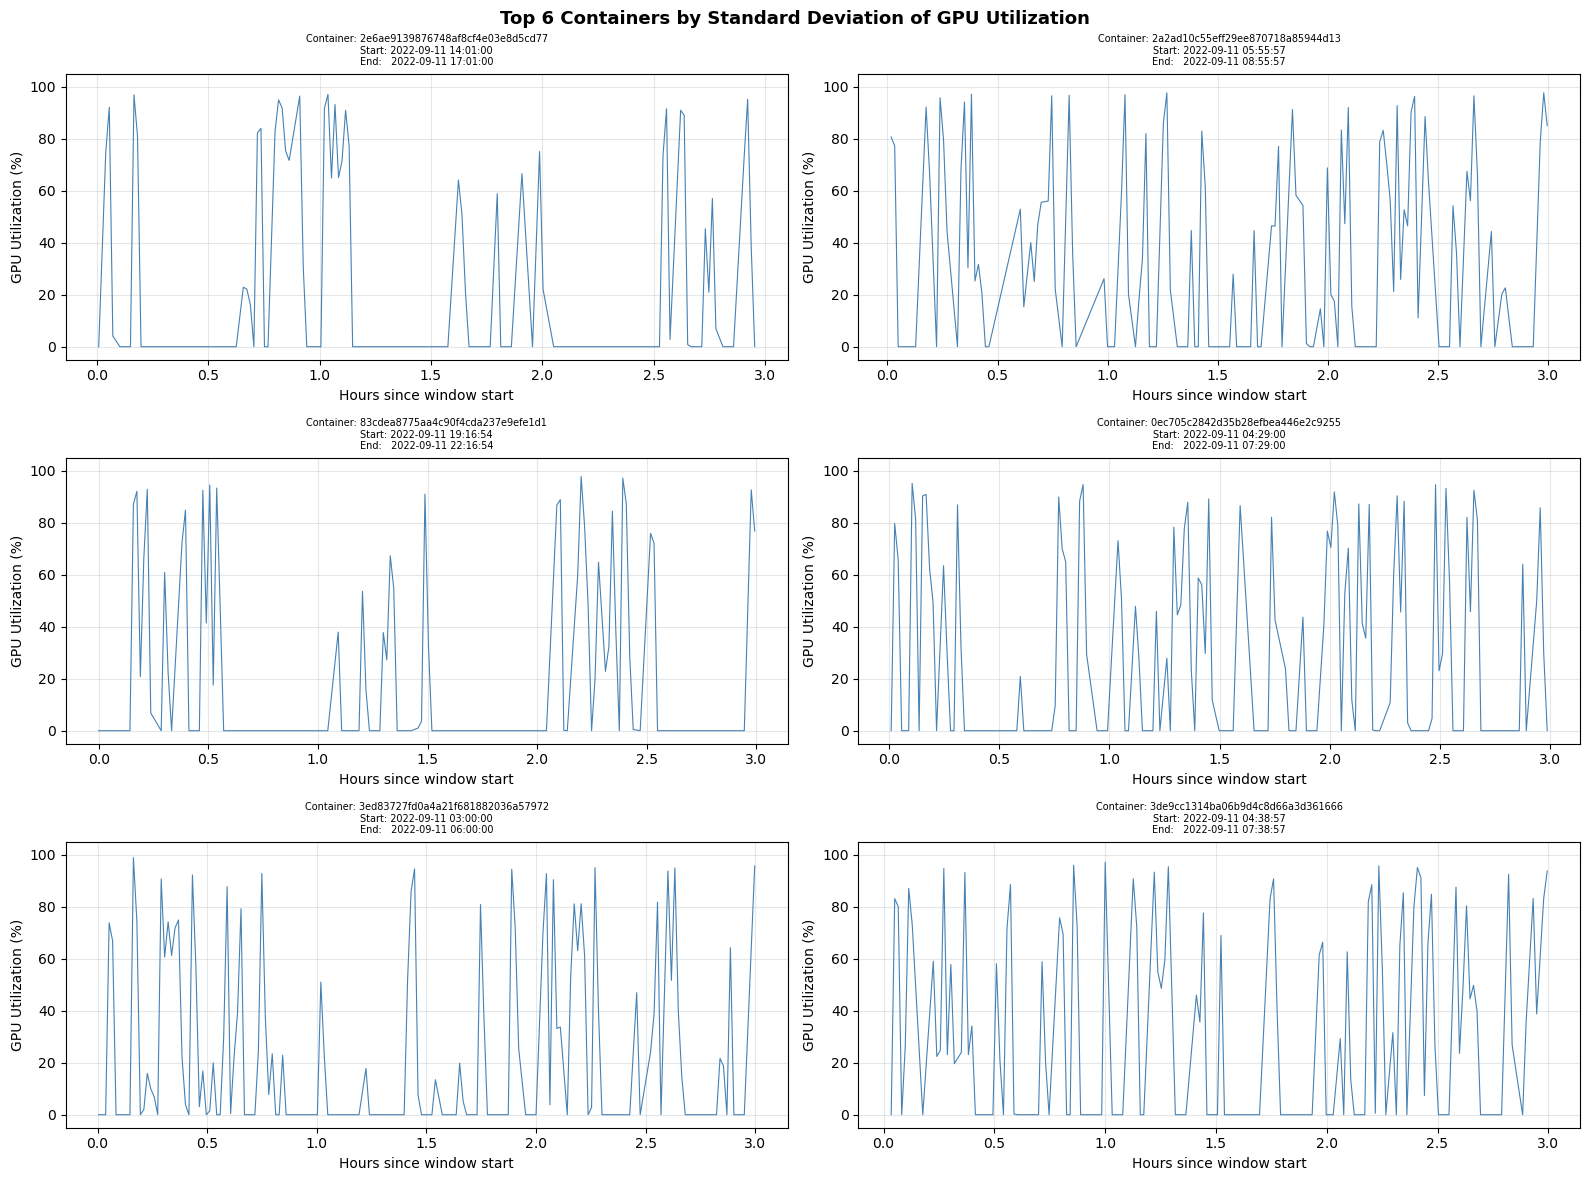

In [5]:
#Group all rows by container ID and computes one standard deviation value per container. 
# This gives us a single number for each of the 143 containers representing how much its 
# GPU utilization fluctuated across the entire 22.8-hour observation period.
std_per_container = df.groupby("container_ip")["value"].std()

# Sort containers from highest to lowest standard deviation
std_per_container = std_per_container.sort_values(ascending=False)

# Print the top 10 
print("Top 10 containers by standard deviation:")
print(std_per_container.head(10))

# Take the top 6 most variable containers 
top_ips = std_per_container.head(6).index.tolist()


#  Find the best 4-hour window for each of the top 6 containers

# Creates an empty list that will store one tuple per container 
# each tuple contains the container IP, the best window start time, 
# and the best window end time
candidates = []

for ip in top_ips:

    # Filter the dataframe to only this container's rows
    grp = df[df["container_ip"] == ip].sort_values("timestamp")

    # Sets the timestamp column as the index of this mini-dataframe. 
    # This is necessary for the time-based slicing done later with 
    # grp.loc[t : t + window_size] 
    grp = grp.set_index("timestamp")

    # Define the sliding window size 
    window_size = pd.Timedelta("3h")

    # Move the window forward in 1-minute steps each iteration
    step_size = pd.Timedelta("1min")

    # Variables to track the best window found so far
    best_std   = 0       # highest std seen in any window so far
    best_start = None    # start time of the best window
    best_end   = None    # end time of the best window

    # Start sliding from the very first timestamp of this container
    t = grp.index.min()

    # Keep sliding until the window would go past the end of the data
    while t + window_size <= grp.index.max():

        # Extract all GPU utilization reading within this 3-hour window
        window_data = grp.loc[t : t + window_size]["value"]

        # Only evaluate windows that have more than 10 data points
        # (a window with too few points is not reliable)
        if len(window_data) > 10:

            # Compute the standard deviation of GPU usage in this window
            # This tells us how much the GPU fluctuated during this particular time segment
            window_std = window_data.std()

            # If this window is more variable than all previous windows, save it
            if window_std > best_std:
                best_std   = window_std
                best_start = t
                best_end   = t + window_size

        # Slide the window forward by 1 minute
        t = t + step_size

    # Save the best window found for this container
    candidates.append((ip, best_start, best_end))


# plot all 6 containers in their best windows 

# Create a 3-row by 2-column grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Flatten the 3x2 grid into a flat list of 6 so we can loop through with an index
axes = axes.flatten()

for idx, (ip, start, end) in enumerate(candidates):

    # Print the window start and end time for each container
    print(f"Container: {ip}")
    print(f"  Window start : {start}")
    print(f"  Window end   : {end}")
    print(f"  Duration     : {end - start}")
    print()

    # Filter to just this container's rows
    grp = df[df["container_ip"] == ip].sort_values("timestamp")

    # Creates a boolean filter that is True only for rows within the best window, 
    # then applies it to keep only those rows
    mask = (grp["timestamp"] >= start) & (grp["timestamp"] <= end)

    # Apply the mask to keep only the rows inside the best window
    window = grp[mask]

    # Convert timestamps to hours elapsed since the window started
    hours = (window["timestamp"] - start).dt.total_seconds() / 3600

    ax = axes[idx]
    ax.plot(hours, window["value"], linewidth=0.8, color="steelblue")

    # Full IP address shown in title
    ax.set_title(f"Container: {ip}\nStart: {start}\nEnd:   {end}", fontsize=7)

    ax.set_xlabel("Hours since window start")
    ax.set_ylabel("GPU Utilization (%)")
    ax.set_ylim(-5, 105)
    ax.grid(True, alpha=0.3)

# Add an overall title 
plt.suptitle("Top 6 Containers by Standard Deviation of GPU Utilization",
             fontsize=13, fontweight="bold")

# Adjust spacing so titles and labels do not overlap
plt.tight_layout()

# Save the figure as a high resolution PNG for the report
plt.savefig("interesting_gpu_patterns.png", dpi=150, bbox_inches="tight")

# Display the plot on screen
plt.show()

6 Containers by Autocorrelation (Periodicity)

Top 6 containers by periodicity score:
                         container_ip  periodicity_score  best_lag  period_minutes
41   455dce072867dd52b4f16cc4b16535d9           0.405605        15            14.2
8    0e1eea513e63bd1b3648013b6623ff0c           0.400061        13            12.4
40   4356d7414e2a134239fb1dcf7f94309b           0.395467        11            10.4
108  ccfa8e249adb8794109c9c63628a2406           0.393620        10             9.5
80   85c29ff41b120b51470d6ccefa14d9f2           0.388105        11            10.4
37   3fa8c0fcbd73508ae6cf1c521d80c208           0.387715        13            12.4
Container 455dce072867dd52b4f16cc4b16535d9 | best window: 2022-09-11 19:47:00 → 2022-09-11 23:47:00 | score: 0.4380
Container 0e1eea513e63bd1b3648013b6623ff0c | best window: 2022-09-11 05:09:00 → 2022-09-11 09:09:00 | score: 0.3570
Container 4356d7414e2a134239fb1dcf7f94309b | best window: 2022-09-11 18:52:00 → 2022-09-11 22:52:00 | score: 0.3969
Container ccfa8e249adb8794109c9c

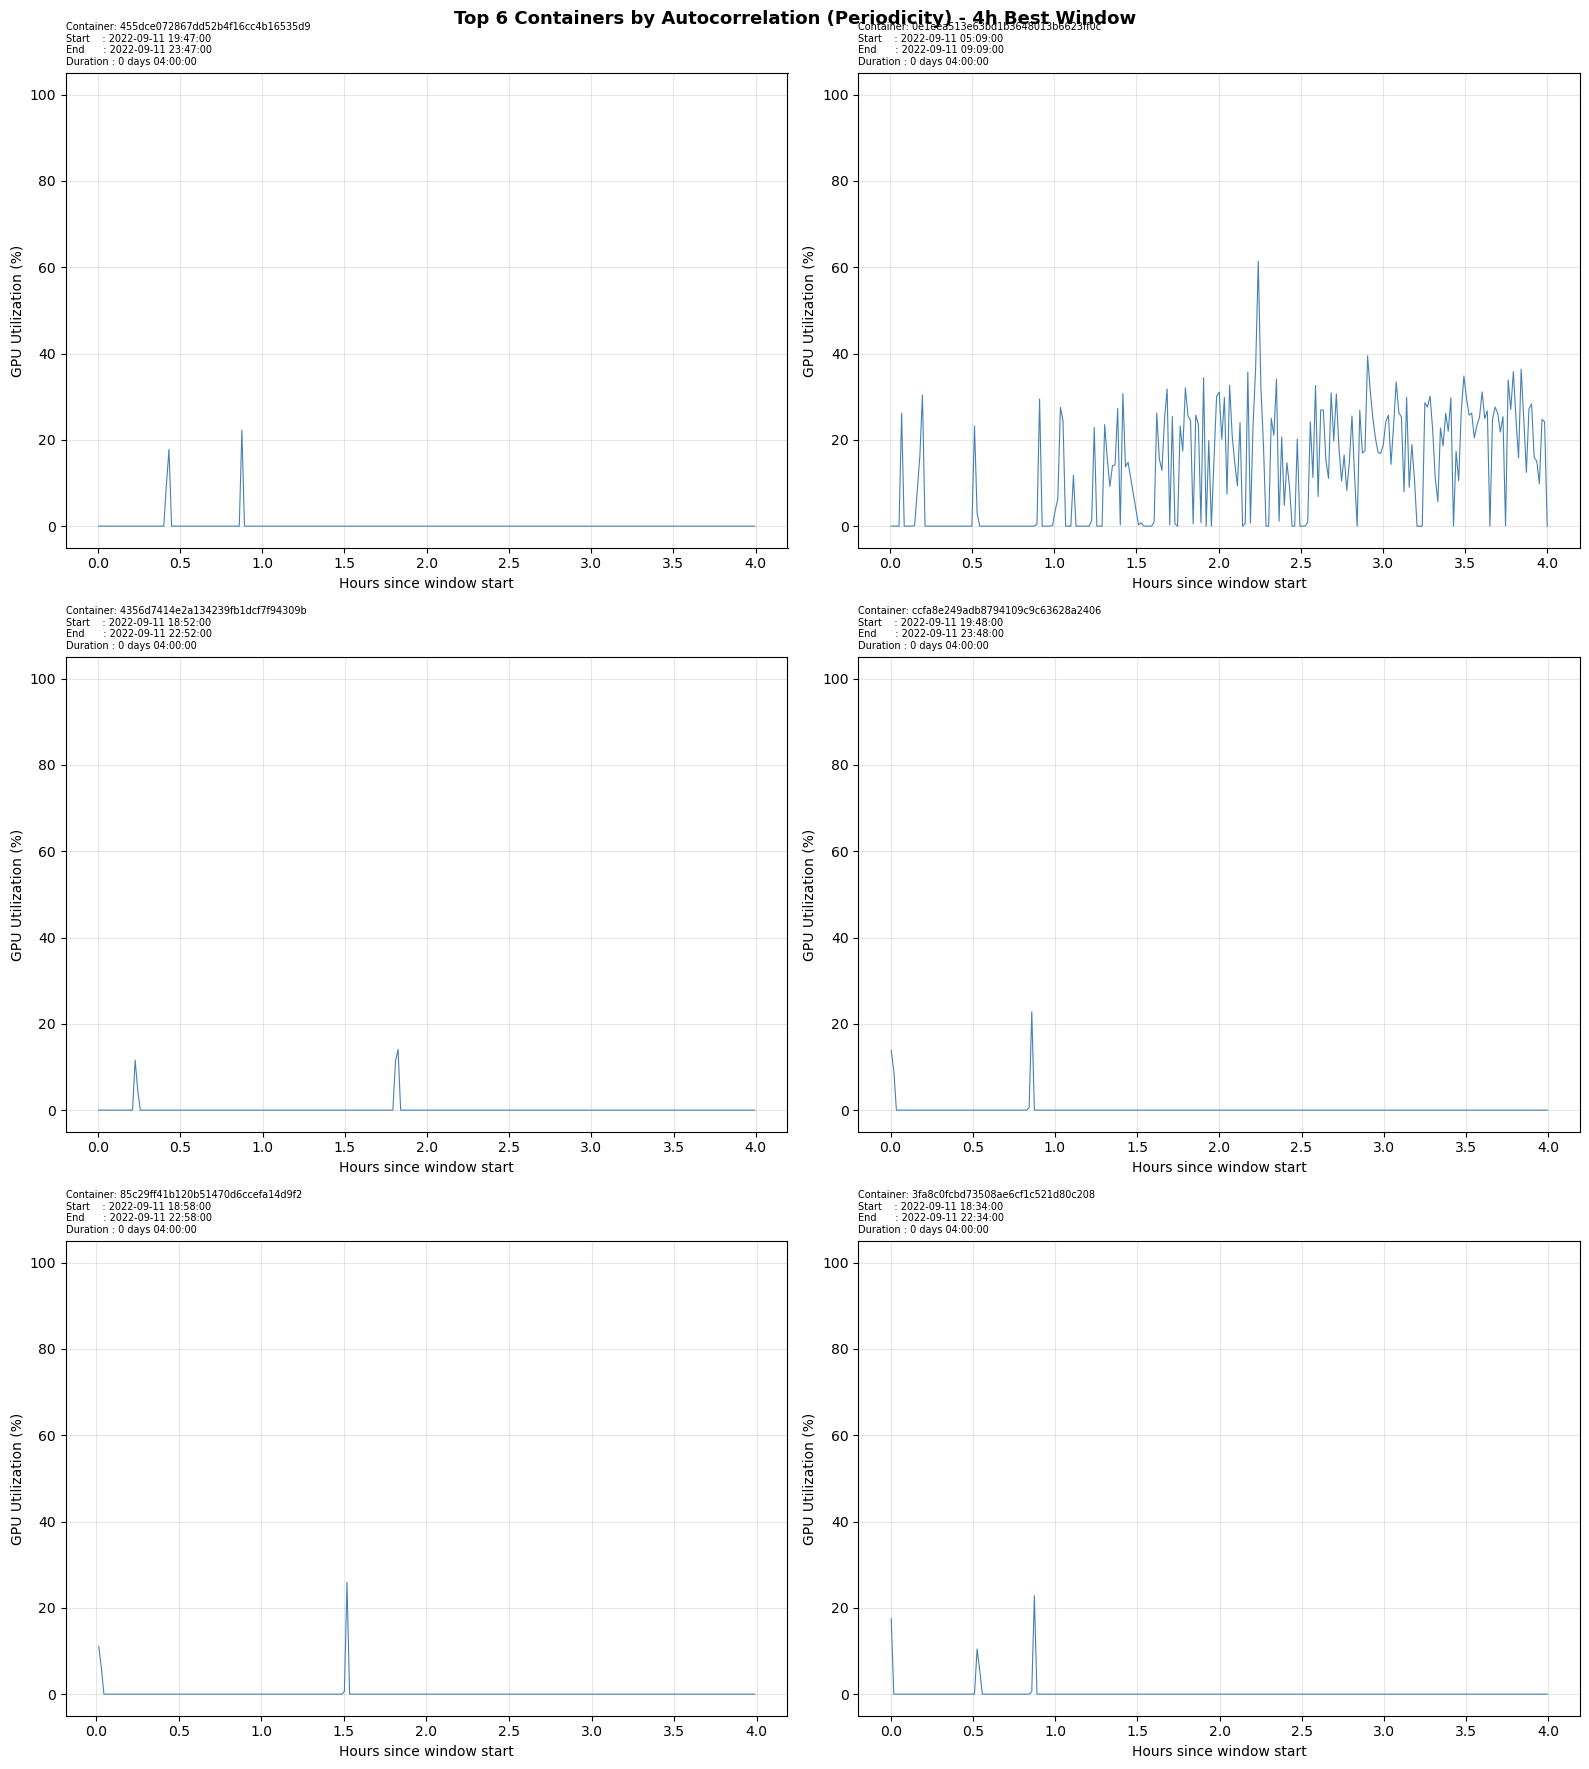

In [ ]:
#define the autocorrelation function

#Defines a reusable function that takes 
# an array of GPU utilization values and computes 
# its autocorrelation up to nlags lags
def compute_autocorr(vals, nlags=100):

    # Subtract the mean so the signal oscillates around 0
    # i.e: if mean = 45%, then 100% becomes +55 and 0% becomes -45
    vals = vals - np.mean(vals)

    # Compute correlation between the signal and every shifted version of itself
    # mode="full" computes the correlation at every possible lag from -N to +N
    # One lag = one sample = 57 seconds of real time in this dataset
    # At lag 1  (1  * 57sec =57 seconds)
    # At lag 20 (20 * 57sec =19 minutes) 
    # At lag 100(100* 57sec =95 minutes) → compare signal shifted forward by 95 minutes
    # The result is a very large array of raw correlation numbers 
    # their magnitude is in the millions because they are sums of a lot of multiplications 
    # and has no direct physical meaning until normalized
    full = np.correlate(vals, vals, mode="full")

    # Keep only the positive lags (forward shifts in time)
    # mode="full" returns both negative and positive lags
    # we only care about shifting forward in time so we discard the first half
    # from 0,1..,N
    full = full[len(full)//2:]

    #  Normalize so that lag 0 = 1.0
    # At lag 0 the signal is compared to itself : always a perfect match
    # Dividing by lag 0 converts all values to a range of -1.0 to 1.0 where:
    #   1.0  = signal repeats perfectly at this lag
    #   0.0  = no relationship between signal and its shifted version
    #  -1.0  = signal is perfectly inverted at this lag
    full = full / full[0]


    # Return only up to nlags lags (lags 0 through 100)
    return full[:nlags+1]


# Score all 143 containers by periodicity 

# Empty list to store results for each container
results = []

#ip - ip_adreess
# all of these ip_adress's rows
#df.groupby("container_ip") takes the full dataframe with all rows
#  and splits it into 143 separate mini-dataframes : one for each unique container IP. 
for ip, grp in df.groupby("container_ip"):

    # Extracts the GPU utilization readings for this container as a plain numpy array
    vals = grp["value"].values

    # Skip containers with too few data points to compute autocorrelation reliably
    if len(vals) < 50:
        continue

    # Skip containers where all values are identical 
    # because this causes division by zero in the normalization step
    if np.std(vals) == 0:
        continue
    #Calls the autocorrelation function on this container's full 22.8-hour signal, 
    #computing correlation at every lag from 0 to 100 (0-95 mins)
    autocorr = compute_autocorr(vals, nlags=100)

    # Skip containers that produced nan values in the autocorrelation
    if np.any(np.isnan(autocorr)):
        continue

    # Skip lag 0 since it is always 1.0 by definition
    # From lag 10 (10*57 seconds) onwards we search for the strongest repeating pattern
    # Finds the highest autocorrelation peak from lag 10 onwards
    periodicity_score = autocorr[10:].max()

    # Find which lag had the highest peak : this tells us the actual period in real time
    best_lag       = autocorr[10:].argmax() + 10  # +10 because skipping first 10 lags
    period_seconds = best_lag * 57               # one lag = 57 seconds (median sampling period)
    period_minutes = period_seconds / 60

    #Saves all computed metrics for this container as a dictionary in the results list.
    results.append({
        "container_ip"      : ip,
        "periodicity_score" : periodicity_score,
        "best_lag"          : best_lag,
        "period_seconds"    : period_seconds,
        "period_minutes"    : round(period_minutes, 1)
    })

# Convert results to a dataframe and sort from most to least periodic
res = pd.DataFrame(results)
res = res.sort_values("periodicity_score", ascending=False)

# Print the top 6 containers by periodicity score
print("Top 6 containers by periodicity score:")
print(res.head(6)[["container_ip", "periodicity_score", "best_lag", "period_minutes"]].to_string())

# Keep the top 6 most periodic containers
top_ips = res.head(6)["container_ip"].tolist()


#Find the best 4-hour window inside each of the top 6 containers

# Empty list to store the best window for each container
candidates = []

for ip in top_ips:

    # Filter to just this container and set timestamp as index
    grp = df[df["container_ip"] == ip].sort_values("timestamp")
    grp = grp.set_index("timestamp")

    # Sliding window of 4 hours, moving 1 minute at a time
    window_size = pd.Timedelta("4h")
    step_size   = pd.Timedelta("1min")

    # Variables to track the best window found so far
    best_score = 0
    best_start = None
    best_end   = None

    # Start at the very first timestamp of this container
    t = grp.index.min()

    # Keep sliding until the window would go past the end of the data
    while t + window_size <= grp.index.max():

        # Get all data points inside this 4-hour window
        window_data = grp.loc[t : t + window_size]["value"]

        # Only evaluate windows with enough data points
        if len(window_data) > 10:

            vals = window_data.values

            # Skip windows where all values are identical 
            if np.std(vals) == 0:
                t = t + step_size
                continue

            # Compute autocorrelation for this window
            #nlags=min(100, len(vals)//2) ensures we never request
            # more lags than half the window length, which would produce unreliable results.
            autocorr = compute_autocorr(vals, nlags=min(100, len(vals)//2))

            # Skip windows where autocorrelation produced nan values
            if np.any(np.isnan(autocorr)):
                t = t + step_size
                continue

            # Score this window by its strongest periodic peak beyond lag 10
            #If it beats the previous best, saves this window's start and 
            # end time as the new best.
            score = autocorr[10:].max() if len(autocorr) > 10 else 0

            # Save this window if it is the most periodic so far
            if score > best_score:
                best_score = score
                best_start = t
                best_end   = t + window_size

        # Slide the window forward by 1 minute
        t = t + step_size

    # Safety check : if no valid window was found, fall back to the first 4 hours
    if best_start is None:
        best_start = grp.index.min()
        best_end   = grp.index.min() + window_size
        print(f"Warning: no valid window found for {ip} using first 4 hours")

    # Save the best window for this container
    candidates.append((ip, best_start, best_end))
    print(f"Container {ip} | best window: {best_start} → {best_end} | score: {best_score:.4f}")


# Plot all 6 containers in their best windows 

# Create a 3-row by 2-column grid of subplots
# Increased height to 18 so the 4-line title has enough room above each plot
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Flatten the 3x2 grid into a flat list of 6 so we can loop through with an index
axes = axes.flatten()

for idx, (ip, start, end) in enumerate(candidates):

    # Print the window details to the console for the report
    print(f"Container : {ip}")
    print(f"Start     : {start}")
    print(f"End       : {end}")
    print(f"Duration  : {end - start}")
    print()

    # Filter to just this container and this time window
    grp  = df[df["container_ip"] == ip].sort_values("timestamp")
    mask = (grp["timestamp"] >= start) & (grp["timestamp"] <= end)
    window = grp[mask]

    # Convert x-axis to hours elapsed since the window started
    hours = (window["timestamp"] - start).dt.total_seconds() / 3600

    # Select the correct subplot for this container
    ax = axes[idx]
    ax.plot(hours, window["value"], linewidth=0.8, color="steelblue")

    # Show full IP, start, end and duration all on separate lines
    # loc="left" prevents the long MD5 hash from being centered and overflowing
    ax.set_title(
        f"Container: {ip}\n"
        f"Start    : {start}\n"
        f"End      : {end}\n"
        f"Duration : {end - start}",
        fontsize=7,
        loc="left"
    )

    ax.set_xlabel("Hours since window start")
    ax.set_ylabel("GPU Utilization (%)")
    ax.set_ylim(-5, 105)
    ax.grid(True, alpha=0.3)

# Add an overall title 
plt.suptitle("Top 6 Containers by Autocorrelation (Periodicity) - 4h Best Window",
             fontsize=13, fontweight="bold")

# Adjust spacing so titles and labels do not overlap
plt.tight_layout()

# Save as high resolution PNG for the report
plt.savefig("interesting_gpu_patterns.png", dpi=150, bbox_inches="tight")

# Display the plot
plt.show()